# **<div align="center">EDA FOR BINANCE COIN</div>**

EDA focused on two objectives: **short-, medium-, and long-term price prediction**, and **trend-change analysis** using slope.

In [83]:
%load_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.analysis.eda import (
    split_train_test, time_plots, matrix_correlation, scatter_matrix,
    decompose_time_series, returns_and_volatility, trend_slope, slope_distribution,
    moving_averages, autocorrelation_plots
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## **Initial Configuration**

In [84]:
CRYPTO_NAME = "binancecoin"
DATA_PATH = f"../data/processed/{CRYPTO_NAME}.csv"

## **Import dataset**

In [85]:
df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date", drop=False).sort_index()

print(f"Observations: {len(df)}")
print(f"Period: {df.index.min().date()} -> {df.index.max().date()}")
display(df.head())
display(df.isna().sum())

Observations: 240
Period: 2025-02-05 -> 2025-10-02


,cryptocurrency_id,price_usd,market_cap,volume,date
date,,,,,
2025-02-05,4.0,571.03,8.327530e+10,1.241400e+09,2025-02-05
2025-02-06,4.0,580.05,8.457820e+10,4.711890e+08,2025-02-06
2025-02-07,4.0,586.11,8.556300e+10,1.075490e+09,2025-02-07
2025-02-08,4.0,586.11,8.556300e+10,1.075490e+09,2025-02-08
2025-02-09,4.0,586.11,8.556300e+10,1.075490e+09,2025-02-09


cryptocurrency_id    0
price_usd            0
market_cap           0
volume               0
date                 0
dtype: int64

## **Train / Test split**

In [86]:
train, test = split_train_test(df, 0.8)
print(f"Train: {len(train)} observations")
print(f"Test: {len(test)} observations")
print(f"Train ends: {train.index.max().date()}")
print(f"Test starts: {test.index.min().date()}")

Train: 192 observations
Test: 48 observations
Train ends: 2025-08-15
Test starts: 2025-08-16


## **1. Price and market variables**
We analyze the temporal evolution and relationships between price, market cap, and volume.

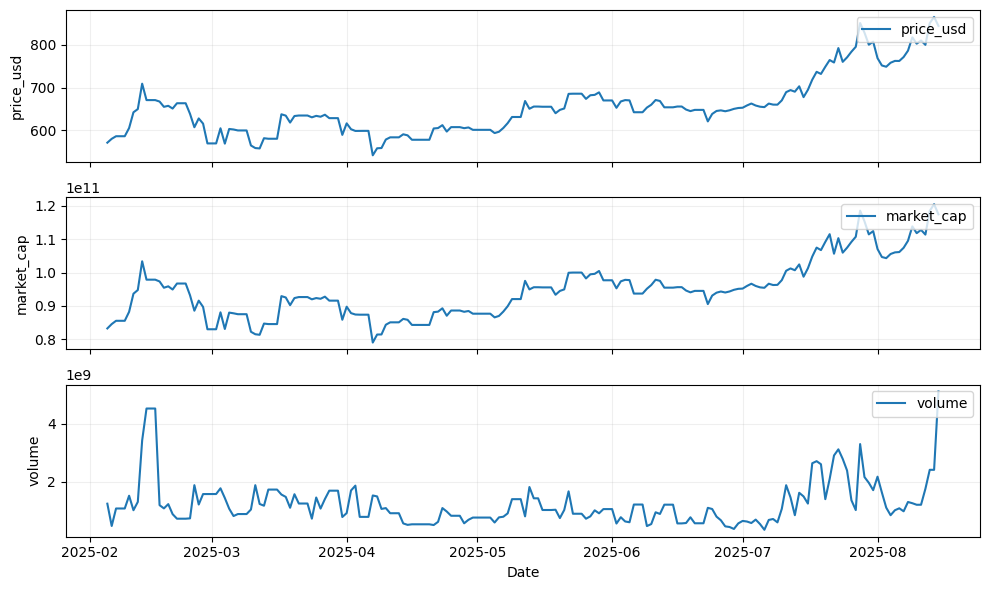

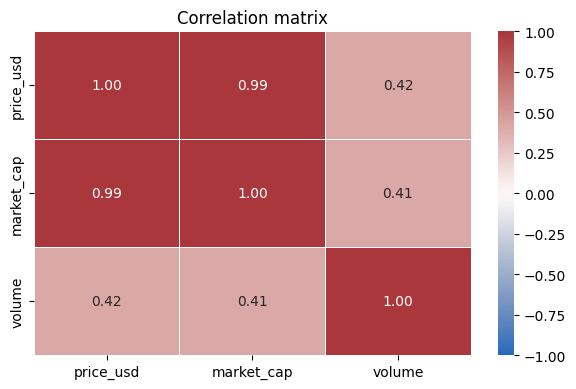

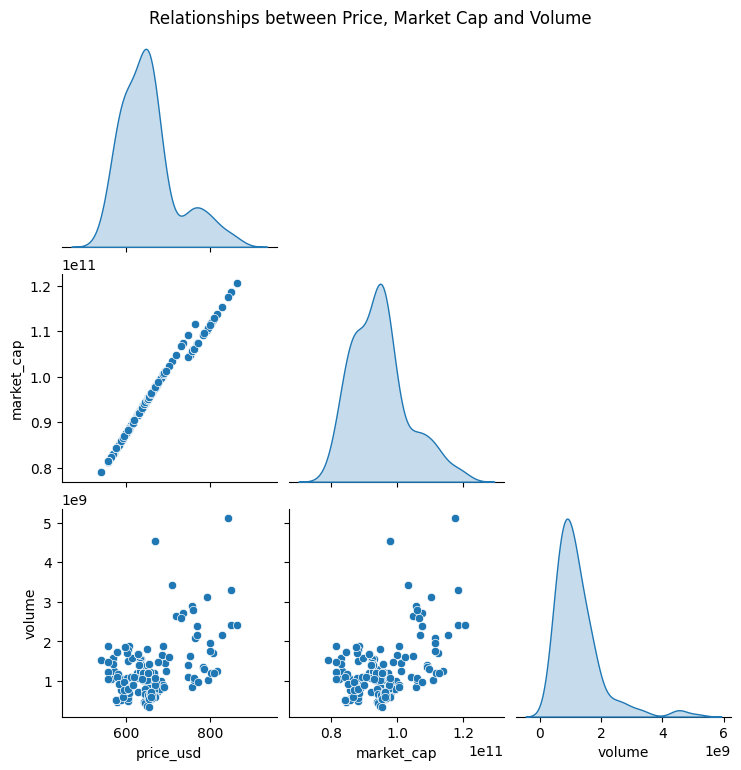

In [87]:
FEATURES = ["price_usd", "market_cap", "volume"]
time_plots(train, FEATURES)
matrix_correlation(train, FEATURES)
scatter_matrix(train, FEATURES)

## **2. Returns and volatility**
Returns and volatility help us study price behavior and possible regime changes.

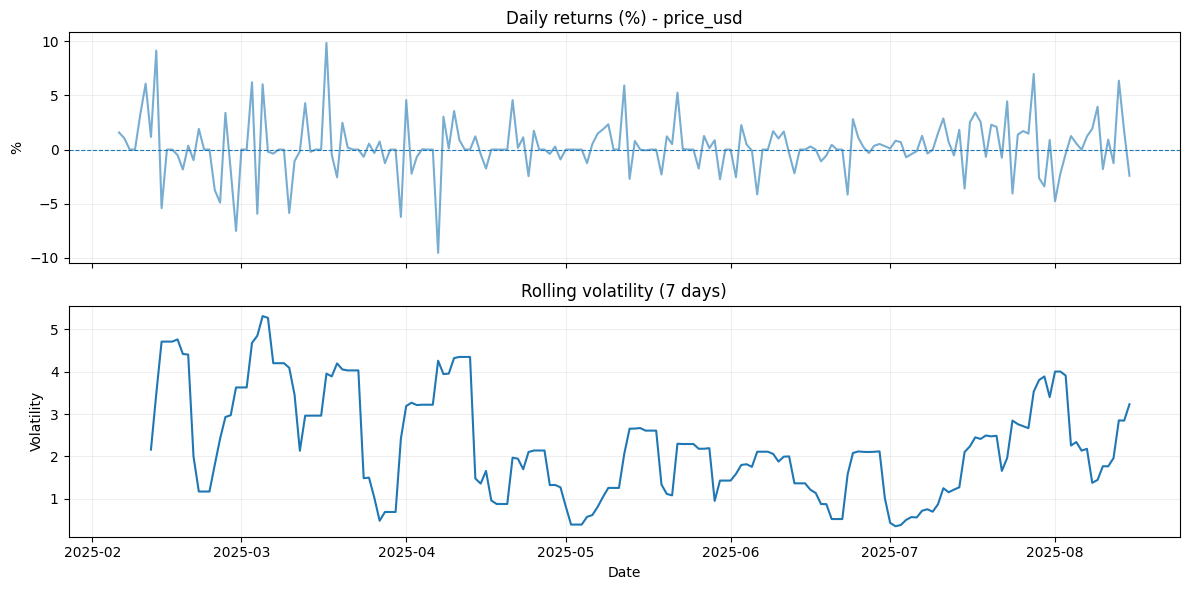

In [88]:
df_returns = returns_and_volatility(train, "price_usd", 7)

## **3. Autocorrelation**

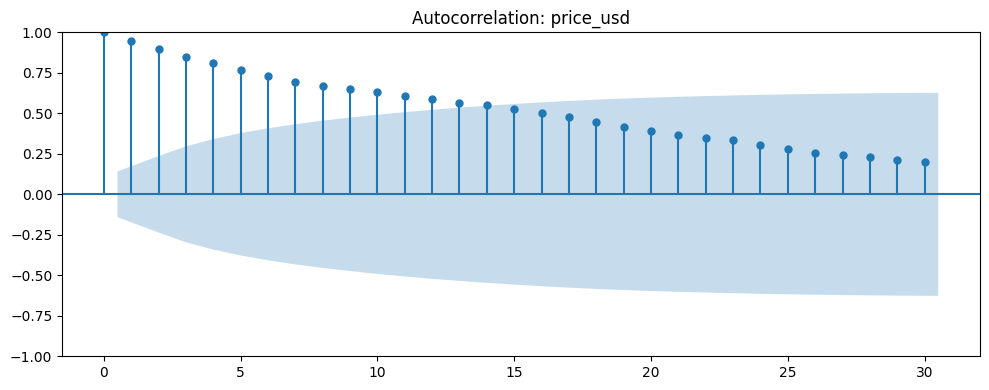

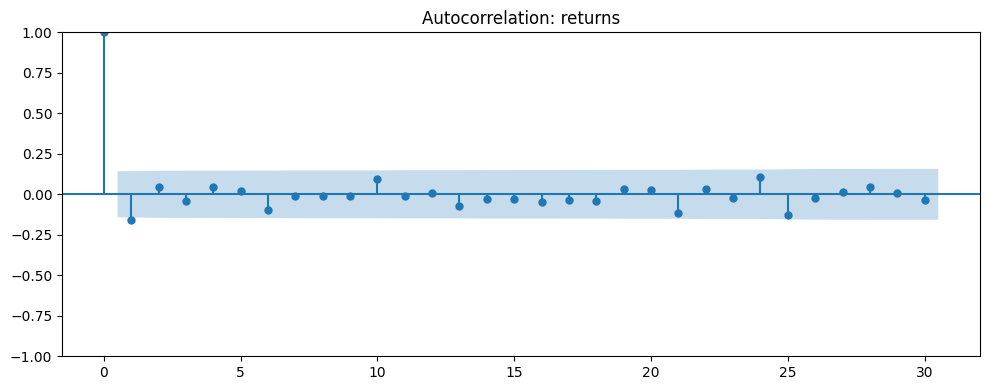

In [89]:
autocorrelation_plots(df_returns, ["price_usd", "returns"], lags=30)

## **4. Trend analysis**
We study the trend slope over 7-, 14-, and 30-day windows. We do not define categories or thresholds yet.

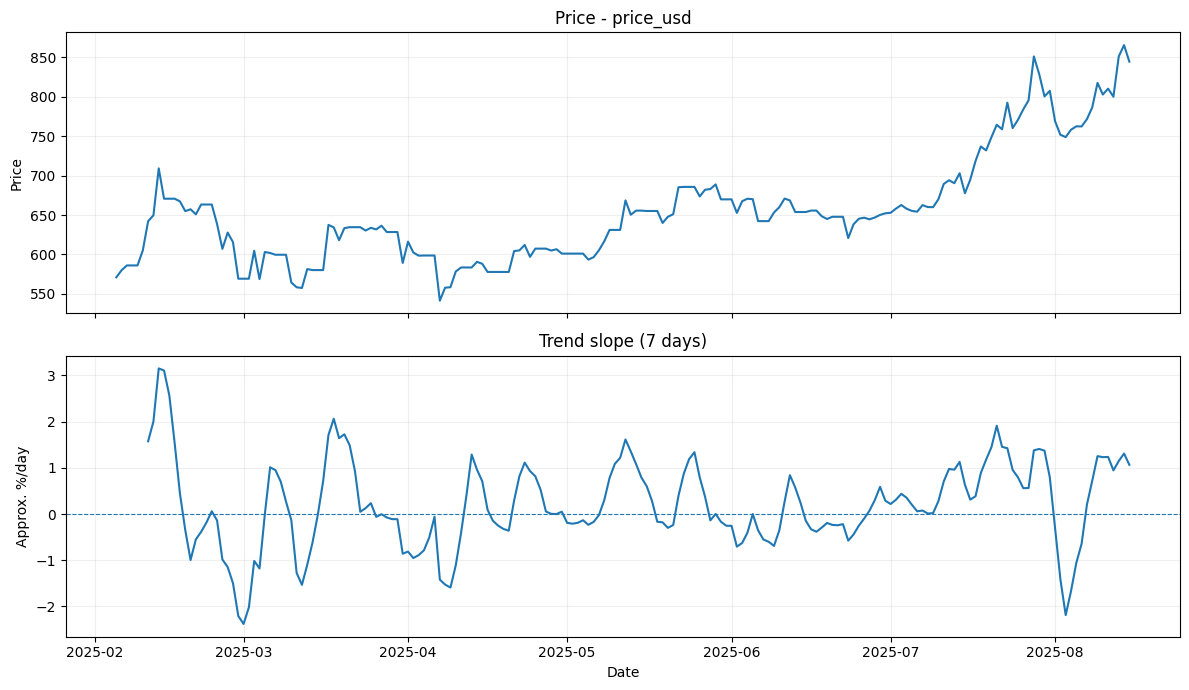

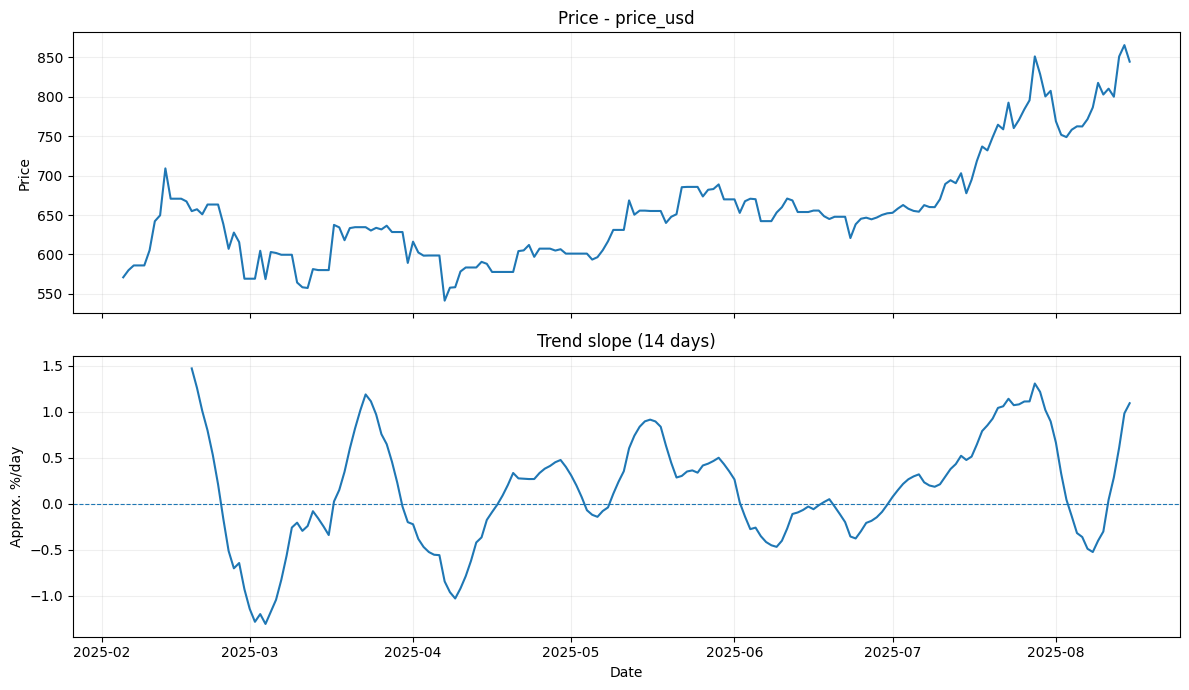

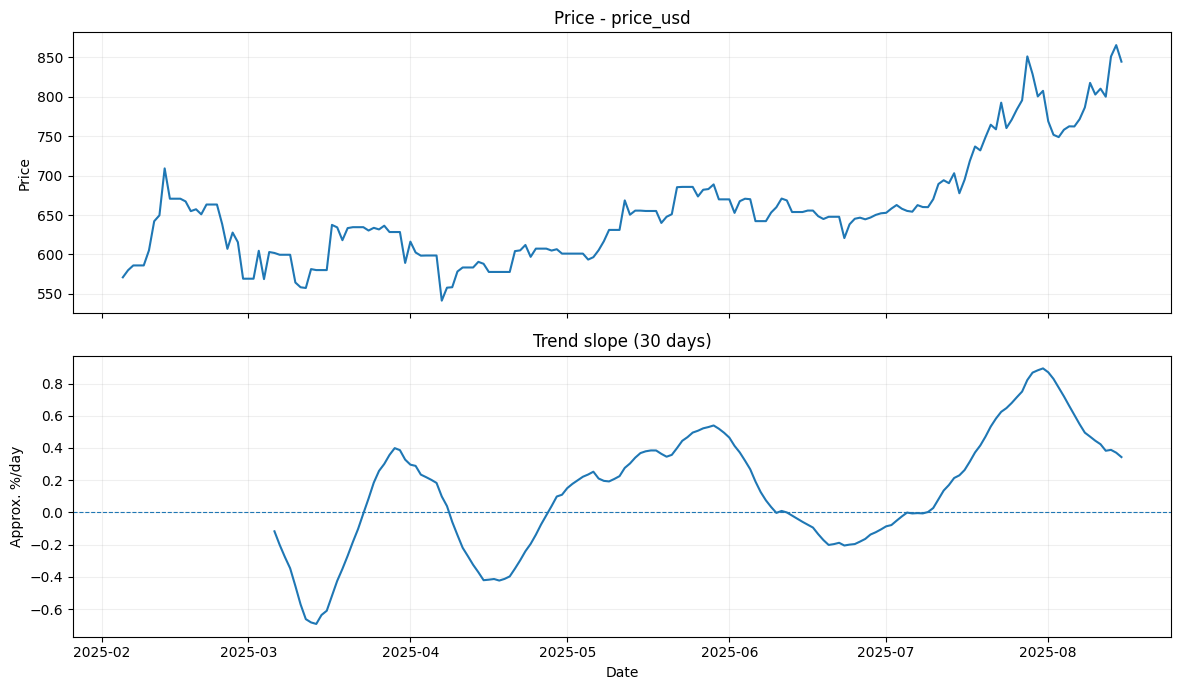

In [90]:
df_slope_7 = trend_slope(train, "price_usd", window=7)
df_slope_14 = trend_slope(train, "price_usd", window=14)
df_slope_30 = trend_slope(train, "price_usd", window=30)

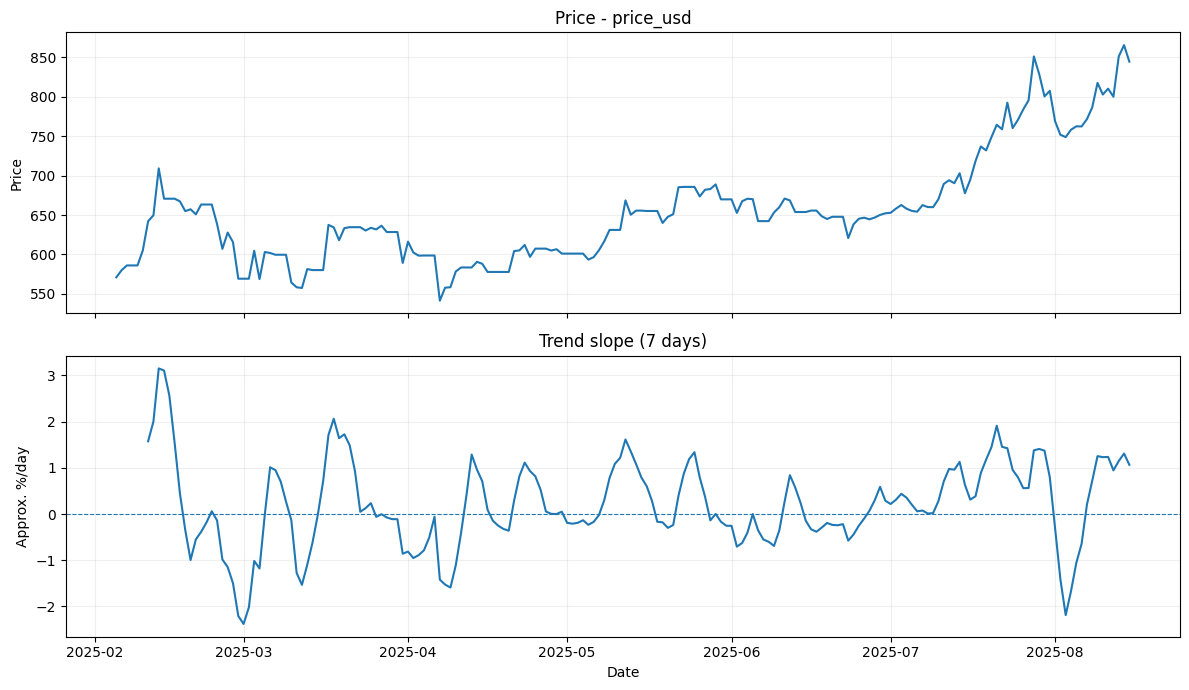

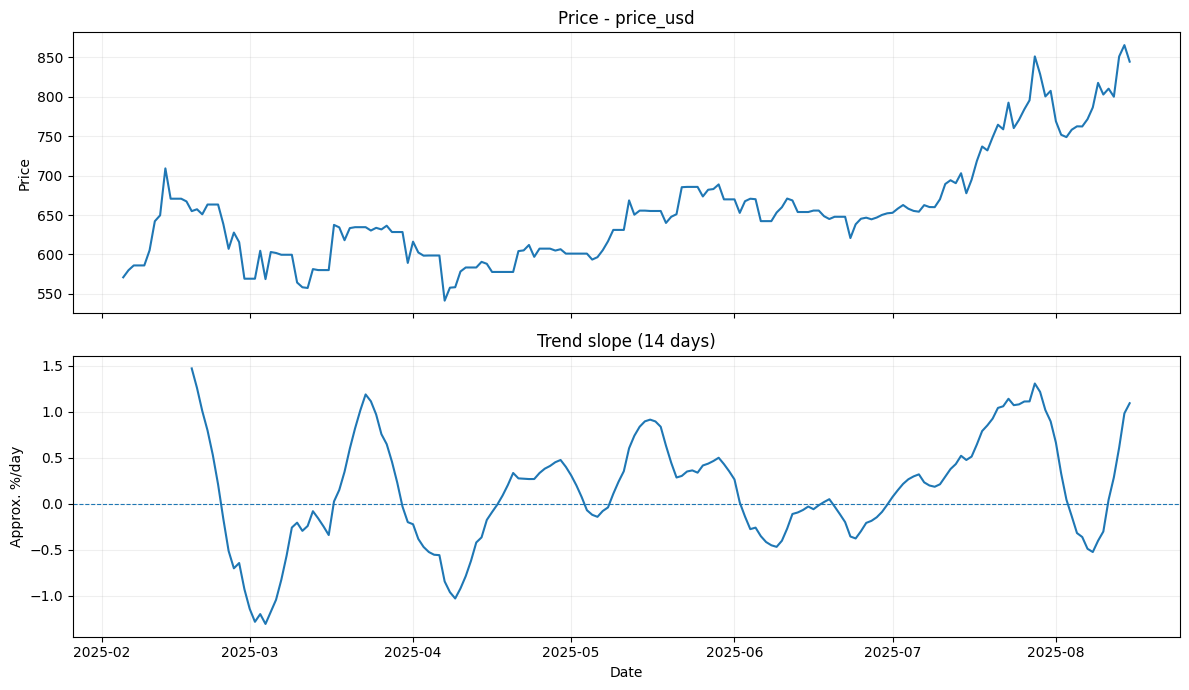

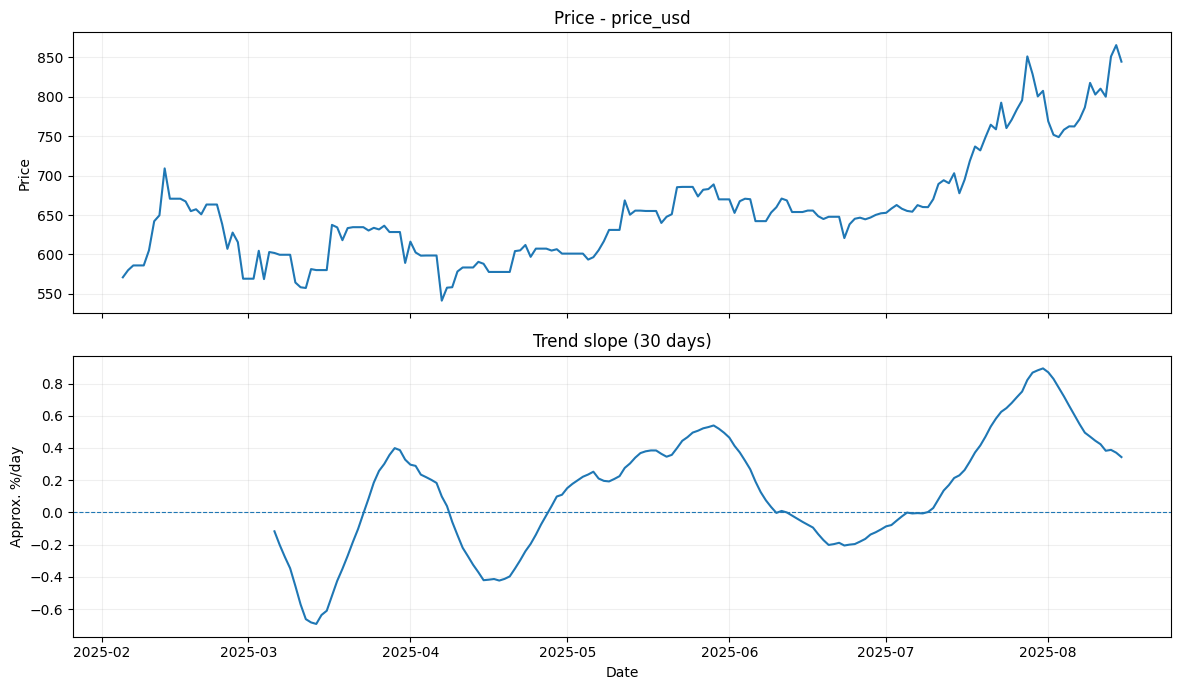

,count,min,p05,p10,p25,median,p75,p90,p95,max,mean,std
slope_7,186.0,-0.024075,-0.014288,-0.009943,-0.003158,0.000592,0.008314,0.013531,0.015903,0.031019,0.001871,0.009379
slope_14,179.0,-0.013134,-0.009247,-0.005559,-0.002518,0.001504,0.004689,0.009674,0.010879,0.014593,0.001303,0.005815
slope_30,163.0,-0.006952,-0.004262,-0.003511,-0.001365,0.001771,0.003829,0.005445,0.007174,0.008902,0.001283,0.003600


In [91]:
# Slope distribution analysis
slope_summary = slope_distribution(
    train,
    price_col = 'price_usd',
    windows=(7, 14, 30)
)

display(slope_summary)

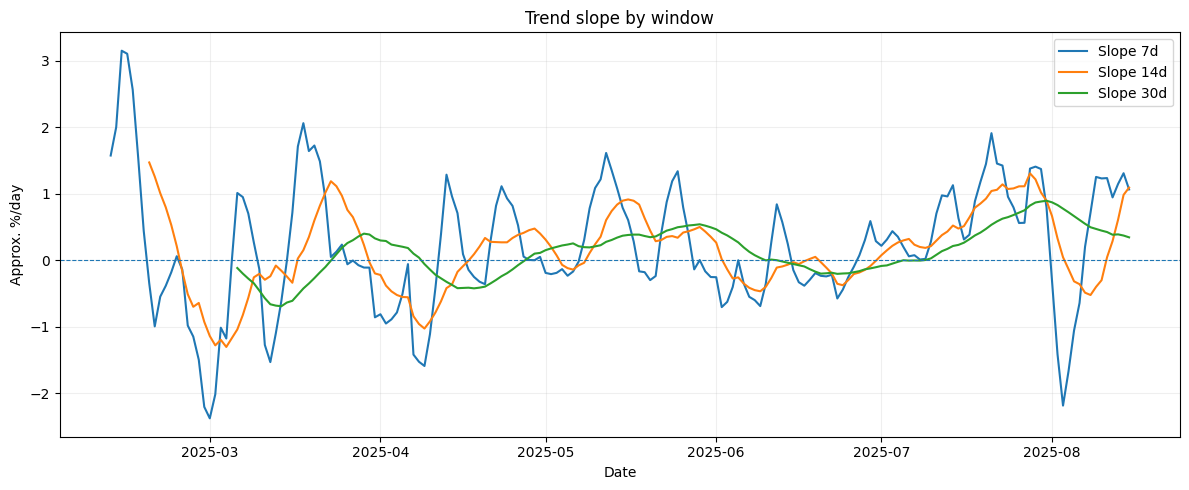

In [92]:
plt.figure(figsize=(12, 5))
for data, window in [(df_slope_7, 7), (df_slope_14, 14), (df_slope_30, 30)]:
    plt.plot(data.index, data["trend_slope_pct"], label=f"Slope {window}d")
plt.axhline(0, linewidth=0.8, linestyle="--")
plt.title("Trend slope by window")
plt.xlabel("Date")
plt.ylabel("Approx. %/day")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

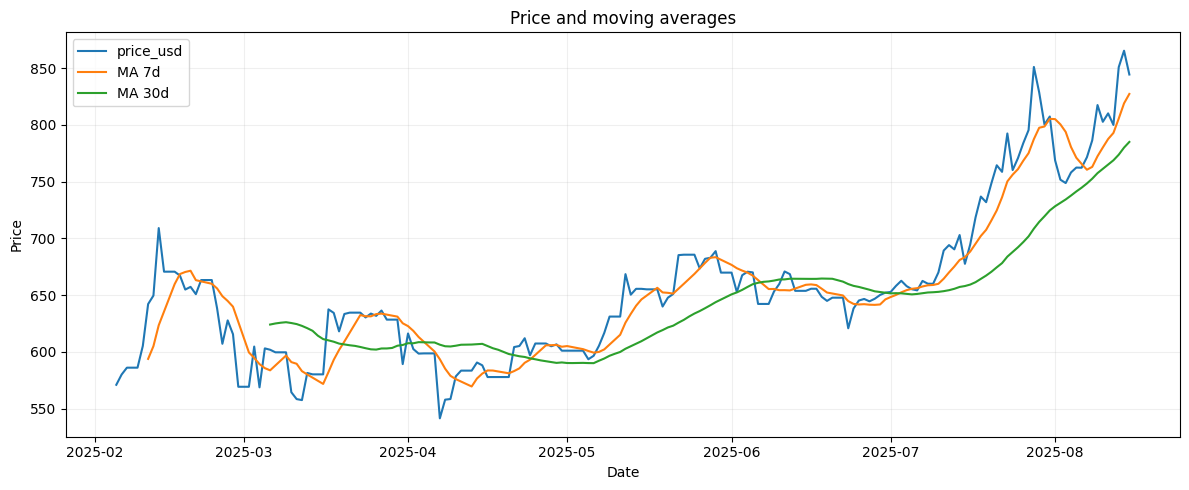

,cryptocurrency_id,price_usd,market_cap,volume,date,ma_7d,ma_30d
date,,,,,,,
2025-02-05,4.0,571.03,8.327530e+10,1.241400e+09,2025-02-05,NaN,NaN
2025-02-06,4.0,580.05,8.457820e+10,4.711890e+08,2025-02-06,NaN,NaN
2025-02-07,4.0,586.11,8.556300e+10,1.075490e+09,2025-02-07,NaN,NaN
2025-02-08,4.0,586.11,8.556300e+10,1.075490e+09,2025-02-08,NaN,NaN
2025-02-09,4.0,586.11,8.556300e+10,1.075490e+09,2025-02-09,NaN,NaN
...,...,...,...,...,...,...,...
2025-08-11,4.0,810.16,1.128110e+11,1.204780e+09,2025-08-11,787.551429,765.161667
2025-08-12,4.0,799.94,1.114010e+11,1.753810e+09,2025-08-12,792.914286,768.814333
2025-08-13,4.0,850.89,1.185200e+11,2.411580e+09,2025-08-13,805.575714,773.745333


In [93]:
moving_averages(train, "price_usd", windows=(7, 30))

## **5. Decomposition**
Decomposition is kept as exploratory analysis. We do not assume that 7 or 30 days is the correct period without comparing the results.

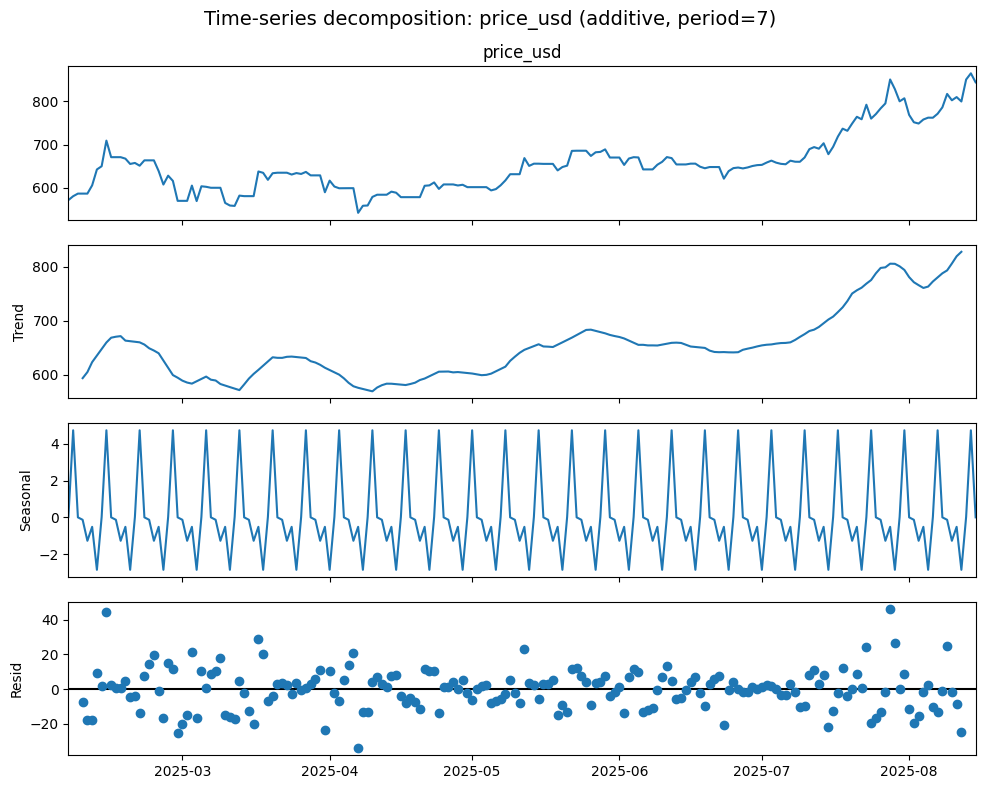

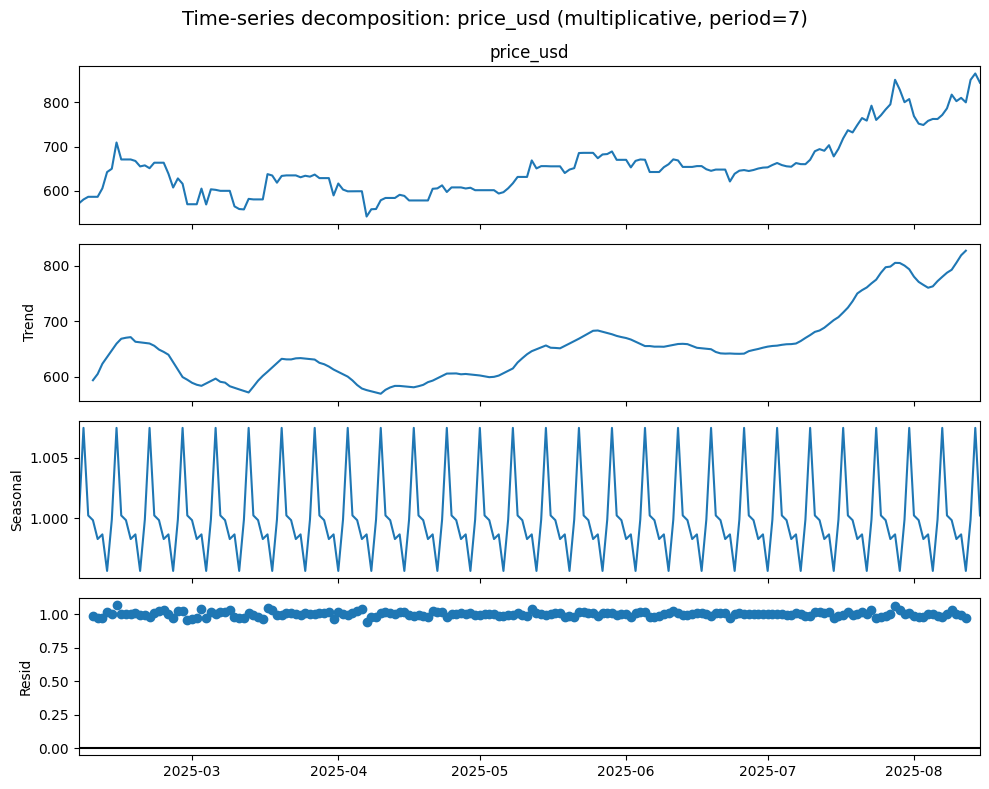

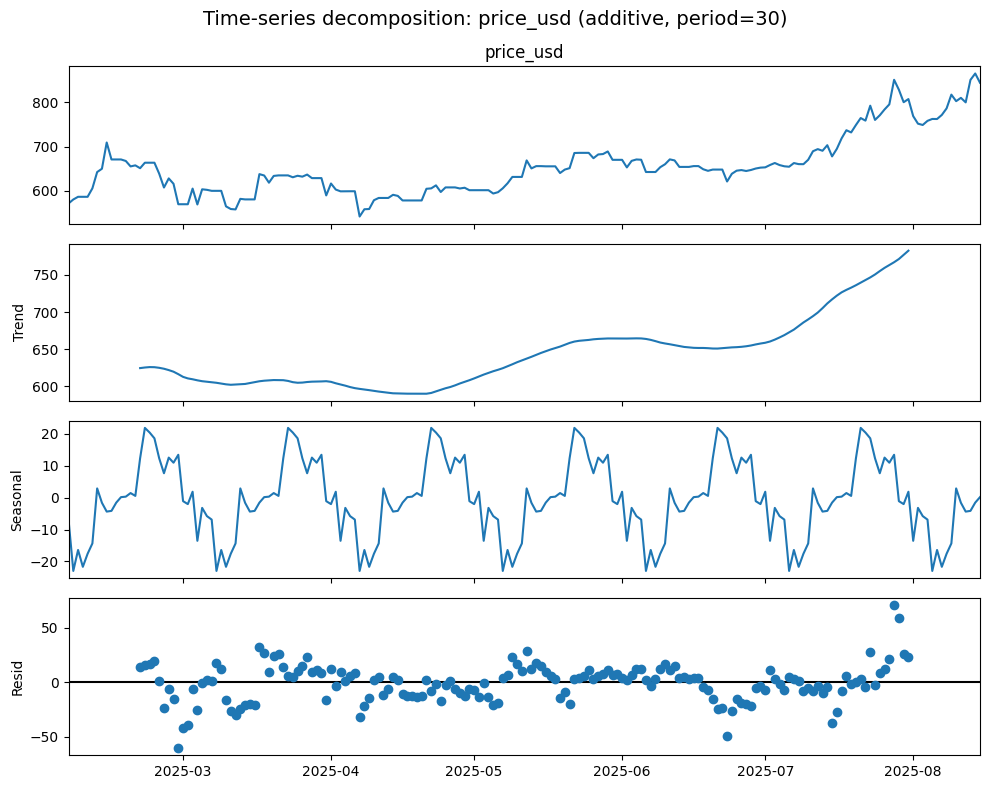

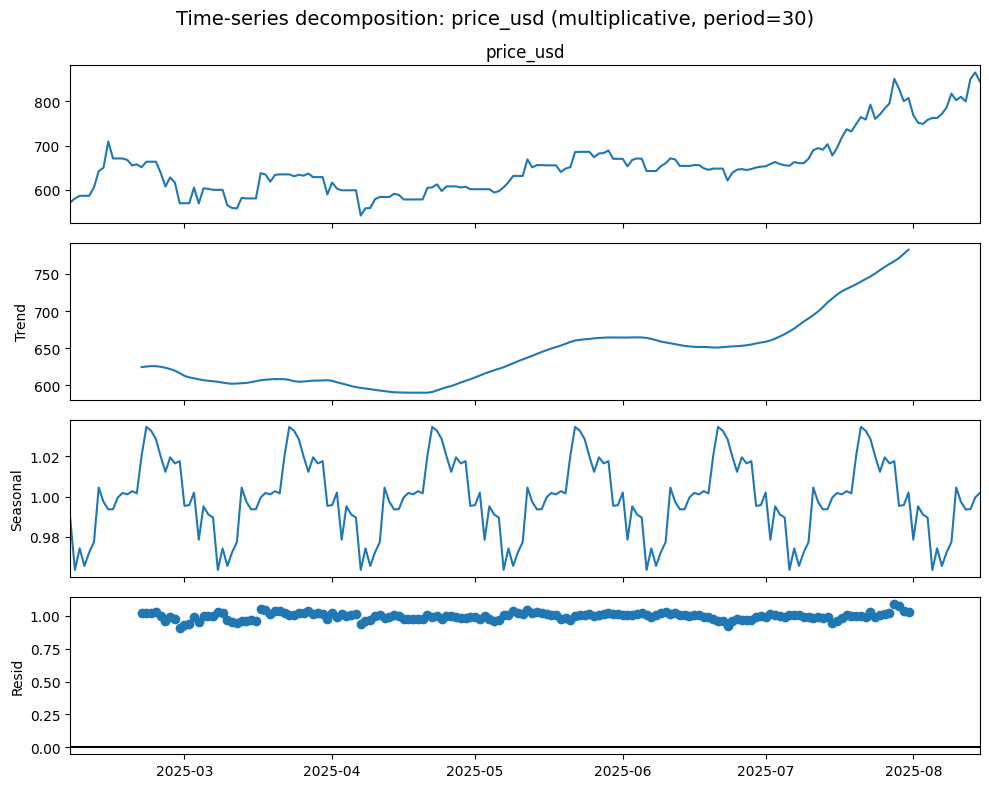

In [94]:
decompose_time_series(train, "price_usd", model="additive", freq=7)
decompose_time_series(train, "price_usd", model="multiplicative", freq=7)
decompose_time_series(train, "price_usd", model="additive", freq=30)
decompose_time_series(train, "price_usd", model="multiplicative", freq=30)

## **6. Conclusions / next step**
First, we will examine the distribution and stability of the slopes before defining categories such as strong decrease, decrease, stable, increase, and strong increase.

The short-, medium-, and long-term price-prediction horizons will be defined according to the actual frequency and length of the time series.